# ============================================
# ANÁLISIS Y JUSTIFICACIÓN DE CARACTERÍSTICAS - TITANIC
# ============================================


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


Cargar Datos Originales

In [2]:
# ============================================
# 1. CARGAR DATOS ORIGINALES
# ============================================
print(" Cargando datos crudos...")

train_raw = pd.read_csv('../data/raw/train.csv')
test_raw = pd.read_csv('../data/raw/test.csv')

print(f" Train original: {train_raw.shape}")
print(f" Test original: {test_raw.shape}")

# Mostrar primeras filas
print("\n Primeras 5 filas de train_raw:")
print(train_raw.head())

 Cargando datos crudos...
 Train original: (891, 12)
 Test original: (418, 11)

 Primeras 5 filas de train_raw:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        

In [4]:
# ============================================
# 2. INFORMACIÓN DEL DATASET
# ============================================
print(" Información de columnas:")
print(train_raw.info())

print("\n Estadísticas descriptivas:")
print(train_raw.describe(include='all'))

 Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Estadísticas descriptivas:
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         

🔍 Valores nulos por columna:
          Valores Nulos  Porcentaje
Age                 177   19.865320
Cabin               687   77.104377
Embarked              2    0.224467


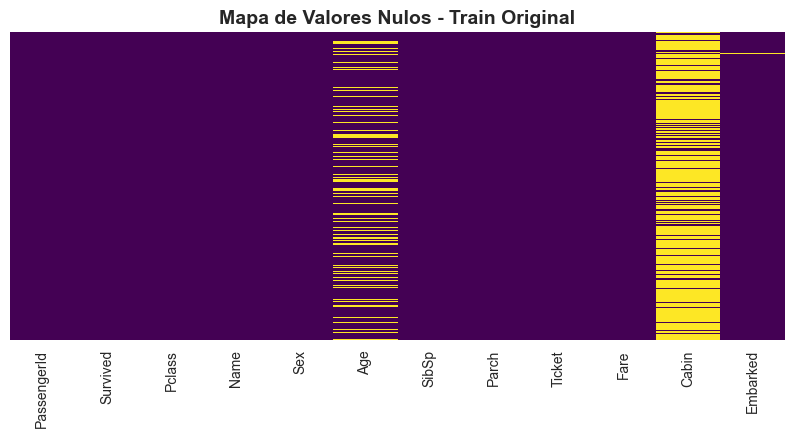

In [5]:
# ============================================
# 3. ANÁLISIS DE VALORES NULOS
# ============================================
print("🔍 Valores nulos por columna:")

null_counts = train_raw.isnull().sum()
null_percent = (train_raw.isnull().sum() / len(train_raw)) * 100

null_df = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje': null_percent
})
print(null_df[null_df['Valores Nulos'] > 0])

# Visualización
plt.figure(figsize=(10, 4))
sns.heatmap(train_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos - Train Original', fontsize=14, fontweight='bold')
plt.show()

In [6]:
# ============================================
# 4. CREAR COPIA PARA TRANSFORMACIONES
# ============================================
df = train_raw.copy()
print("✅ Copia creada para aplicar transformaciones")
print(f"   Dimensiones: {df.shape}")

✅ Copia creada para aplicar transformaciones
   Dimensiones: (891, 12)


 Analizando Age...

 JUSTIFICACIÓN:
   - Age tiene 177 valores nulos (19.9%)
   - La edad es clave para supervivencia (política 'mujeres y niños primero')
   - Usamos MEDIANA porque es robusta a outliers
   - La media (29.7) está cerca de la mediana (28.0), pero la mediana es más estable


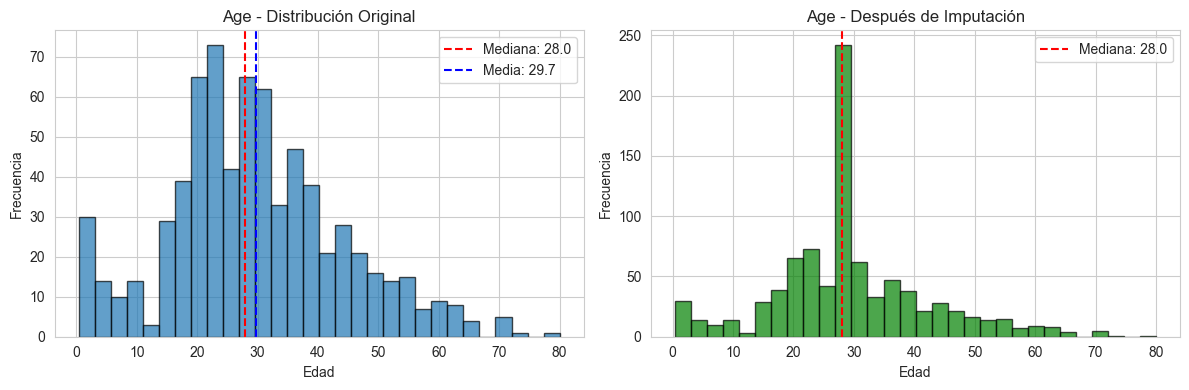

 177 valores nulos reemplazados con mediana (28.0)


In [7]:
# ============================================
# 5. TRANSFORMACIÓN 1: AGE (IMPUTACIÓN)
# ============================================
print(" Analizando Age...")

# Distribución original
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Age'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df['Age'].median(), color='red', linestyle='--', label=f'Mediana: {df["Age"].median():.1f}')
plt.axvline(df['Age'].mean(), color='blue', linestyle='--', label=f'Media: {df["Age"].mean():.1f}')
plt.title('Age - Distribución Original')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - Age tiene 177 valores nulos (19.9%)")
print("   - La edad es clave para supervivencia (política 'mujeres y niños primero')")
print("   - Usamos MEDIANA porque es robusta a outliers")
print("   - La media (29.7) está cerca de la mediana (28.0), pero la mediana es más estable")

# Aplicar imputación
age_median = df['Age'].median()
nulos_age = df['Age'].isnull().sum()
df['Age'].fillna(age_median, inplace=True)

# Distribución después
plt.subplot(1, 2, 2)
df['Age'].hist(bins=30, edgecolor='black', alpha=0.7, color='green')
plt.axvline(age_median, color='red', linestyle='--', label=f'Mediana: {age_median:.1f}')
plt.title('Age - Después de Imputación')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

print(f" {nulos_age} valores nulos reemplazados con mediana ({age_median:.1f})")

In [8]:
# ============================================
# 6. TRANSFORMACIÓN 2: EMBARKED (IMPUTACIÓN)
# ============================================
print(" Analizando Embarked...")

# Ver valores originales
print("\n Distribución original de Embarked:")
print(df['Embarked'].value_counts(dropna=False))

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - Solo 2 valores nulos (0.2%)")
print("   - El puerto más común es 'S' (Southampton)")
print("   - Imputar con la moda es razonable para tan pocos casos")

# Aplicar imputación
embarked_mode = df['Embarked'].mode()[0]
nulos_embarked = df['Embarked'].isnull().sum()
df['Embarked'].fillna(embarked_mode, inplace=True)

print(f" {nulos_embarked} valores nulos reemplazados con '{embarked_mode}'")

# Verificar después
print("\n Distribución después de imputación:")
print(df['Embarked'].value_counts())

 Analizando Embarked...

 Distribución original de Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

 JUSTIFICACIÓN:
   - Solo 2 valores nulos (0.2%)
   - El puerto más común es 'S' (Southampton)
   - Imputar con la moda es razonable para tan pocos casos
 2 valores nulos reemplazados con 'S'

 Distribución después de imputación:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


Matriz de Correlación

In [10]:
# ============================================
# 7. TRANSFORMACIÓN 3: FARE (PARA TEST)
# ============================================
print(" Analizando Fare...")

# En train no hay nulos en Fare
print(f"   Train - Valores nulos en Fare: {df['Fare'].isnull().sum()}")

# En test sí hay (1 valor)
fare_test_nulos = test_raw['Fare'].isnull().sum()
print(f"   Test - Valores nulos en Fare: {fare_test_nulos}")

if fare_test_nulos > 0:
    print("\n JUSTIFICACIÓN:")
    print("   - Test tiene 1 valor nulo en Fare")
    print("   - Se imputará con la mediana de Fare en train")
    print("   - La mediana es mejor que la media por posibles outliers")
    
    fare_median = df['Fare'].median()
    print(f"   - Mediana de Fare: {fare_median:.2f}")

 Analizando Fare...
   Train - Valores nulos en Fare: 0
   Test - Valores nulos en Fare: 1

 JUSTIFICACIÓN:
   - Test tiene 1 valor nulo en Fare
   - Se imputará con la mediana de Fare en train
   - La mediana es mejor que la media por posibles outliers
   - Mediana de Fare: 14.45


In [11]:
# ============================================
# 8. TRANSFORMACIÓN 4: CABIN -> HAS_CABIN
# ============================================
print(" Analizando Cabin...")

# Análisis de nulos
cabin_nulos = df['Cabin'].isnull().sum()
cabin_pct = (cabin_nulos / len(df)) * 100

print(f"   Cabin tiene {cabin_nulos} valores nulos ({cabin_pct:.1f}%)")

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - 77% de valores nulos: imposible imputar con sentido")
print("   - Pero tener cabina puede ser informativo")
print("   - Solución: crear variable binaria 'Has_Cabin'")
print("     * 1 = tiene cabina asignada")
print("     * 0 = no tiene cabina")

# Aplicar transformación
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

print(f"\n Resultado:")
print(f"   - Con cabina: {df['Has_Cabin'].sum()} pasajeros")
print(f"   - Sin cabina: {len(df) - df['Has_Cabin'].sum()} pasajeros")

# Opcional: eliminar columna original
df.drop('Cabin', axis=1, inplace=True)
print("   - Columna 'Cabin' eliminada")

 Analizando Cabin...
   Cabin tiene 687 valores nulos (77.1%)

 JUSTIFICACIÓN:
   - 77% de valores nulos: imposible imputar con sentido
   - Pero tener cabina puede ser informativo
   - Solución: crear variable binaria 'Has_Cabin'
     * 1 = tiene cabina asignada
     * 0 = no tiene cabina

 Resultado:
   - Con cabina: 204 pasajeros
   - Sin cabina: 687 pasajeros
   - Columna 'Cabin' eliminada


In [12]:
# ============================================
# 9. ELIMINAR COLUMNAS NO ÚTILES
# ============================================
print(" Eliminando columnas redundantes...")

columns_to_drop = ['Name', 'Ticket', 'PassengerId']
existing_cols = [col for col in columns_to_drop if col in df.columns]

print(f"   Columnas a eliminar: {existing_cols}")

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - Name: Demasiados valores únicos, difícil de codificar")
print("   - Ticket: Formato inconsistente, poco informativo")
print("   - PassengerId: Solo es un identificador, sin valor predictivo")

# Eliminar
df.drop(existing_cols, axis=1, inplace=True)

print(f"\n Columnas restantes: {list(df.columns)}")

 Eliminando columnas redundantes...
   Columnas a eliminar: ['Name', 'Ticket', 'PassengerId']

 JUSTIFICACIÓN:
   - Name: Demasiados valores únicos, difícil de codificar
   - Ticket: Formato inconsistente, poco informativo
   - PassengerId: Solo es un identificador, sin valor predictivo

 Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Has_Cabin']


Conclusiones sobre las Características

 Creando FamilySize...

 JUSTIFICACIÓN:
   - SibSp = número de hermanos/cónyuges
   - Parch = número de padres/hijos
   - FamilySize = SibSp + Parch + 1 (el propio pasajero)
   - Hipótesis: familias grandes podrían tener menor supervivencia

 FamilySize creada:
FamilySize
1    537
2    161
3    102
4     29
5     15
Name: count, dtype: int64


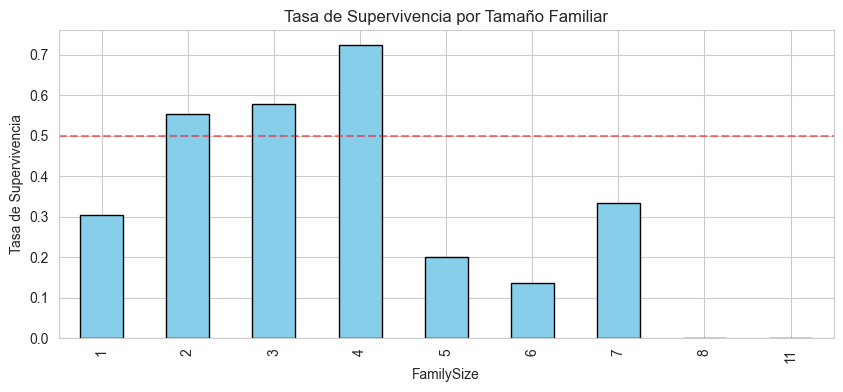

In [13]:
# ============================================
# 10. FEATURE ENGINEERING: FAMILYSIZE
# ============================================
print(" Creando FamilySize...")

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - SibSp = número de hermanos/cónyuges")
print("   - Parch = número de padres/hijos")
print("   - FamilySize = SibSp + Parch + 1 (el propio pasajero)")
print("   - Hipótesis: familias grandes podrían tener menor supervivencia")

# Crear feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(f"\n FamilySize creada:")
print(df['FamilySize'].value_counts().sort_index().head())

# Visualizar relación con supervivencia
plt.figure(figsize=(10, 4))
survival_by_family = df.groupby('FamilySize')['Survived'].mean()
survival_by_family.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Tasa de Supervivencia por Tamaño Familiar')
plt.xlabel('FamilySize')
plt.ylabel('Tasa de Supervivencia')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.show()

In [14]:
# ============================================
# 11. FEATURE ENGINEERING: ISALONE
# ============================================
print(" Creando IsAlone...")

# Justificación
print("\n JUSTIFICACIÓN:")
print("   - Derivada de FamilySize")
print("   - IsAlone = 1 si FamilySize == 1, 0 en otro caso")
print("   - Hipótesis: los pasajeros solos podrían tener comportamiento diferente")

# Crear feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(f"\n IsAlone creada:")
print(f"   - Pasajeros solos: {df['IsAlone'].sum()}")
print(f"   - Pasajeros acompañados: {len(df) - df['IsAlone'].sum()}")

# Ver relación con supervivencia
survival_alone = df.groupby('IsAlone')['Survived'].mean()
print(f"\n Tasa de supervivencia:")
print(f"   - Solos: {survival_alone[1]:.2%}")
print(f"   - Acompañados: {survival_alone[0]:.2%}")

 Creando IsAlone...

 JUSTIFICACIÓN:
   - Derivada de FamilySize
   - IsAlone = 1 si FamilySize == 1, 0 en otro caso
   - Hipótesis: los pasajeros solos podrían tener comportamiento diferente

 IsAlone creada:
   - Pasajeros solos: 537
   - Pasajeros acompañados: 354

 Tasa de supervivencia:
   - Solos: 30.35%
   - Acompañados: 50.56%


In [15]:
# ============================================
# 12. CARGAR DATOS FINALES (YA PROCESADOS)
# ============================================
print(" Cargando datos finales de entrenamiento...")

X_train = pd.read_csv('../data/training/X_train.csv')
y_train = pd.read_csv('../data/training/y_train.csv').values.ravel()

print(f" X_train: {X_train.shape}")
print(f" y_train: {y_train.shape}")

print("\n Columnas finales:")
for i, col in enumerate(X_train.columns, 1):
    print(f"   {i}. {col}")

 Cargando datos finales de entrenamiento...
 X_train: (891, 10)
 y_train: (891,)

 Columnas finales:
   1. Pclass
   2. Sex
   3. Age
   4. SibSp
   5. Parch
   6. Fare
   7. Embarked
   8. Has_Cabin
   9. FamilySize
   10. IsAlone


In [16]:
# ============================================
# 13. ESTADÍSTICAS DE CARACTERÍSTICAS FINALES
# ============================================
print(" Estadísticas descriptivas:")
print(X_train.describe())

print("\n Tipos de datos:")
print(X_train.dtypes)

print("\n Valores únicos por columna:")
for col in X_train.columns:
    print(f"   {col}: {X_train[col].nunique()} únicos")

 Estadísticas descriptivas:
             Pclass           Sex           Age         SibSp         Parch  \
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02   
mean  -8.772133e-17 -1.156327e-16  2.392400e-16  7.177199e-17  9.768966e-17   
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00   
min   -1.566107e+00 -1.355574e+00 -2.224156e+00 -4.745452e-01 -4.736736e-01   
25%   -3.693648e-01 -1.355574e+00 -5.657365e-01 -4.745452e-01 -4.736736e-01   
50%    8.273772e-01  7.376951e-01 -1.046374e-01 -4.745452e-01 -4.736736e-01   
75%    8.273772e-01  7.376951e-01  4.333115e-01  4.327934e-01 -4.736736e-01   
max    8.273772e-01  7.376951e-01  3.891554e+00  6.784163e+00  6.974147e+00   

               Fare      Embarked     Has_Cabin    FamilySize       IsAlone  
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02  
mean   2.791133e-17 -4.984166e-17 -1.455377e-16 -2.791133e-17 -6.379733e-17  
std    1.000562e+00  1.000

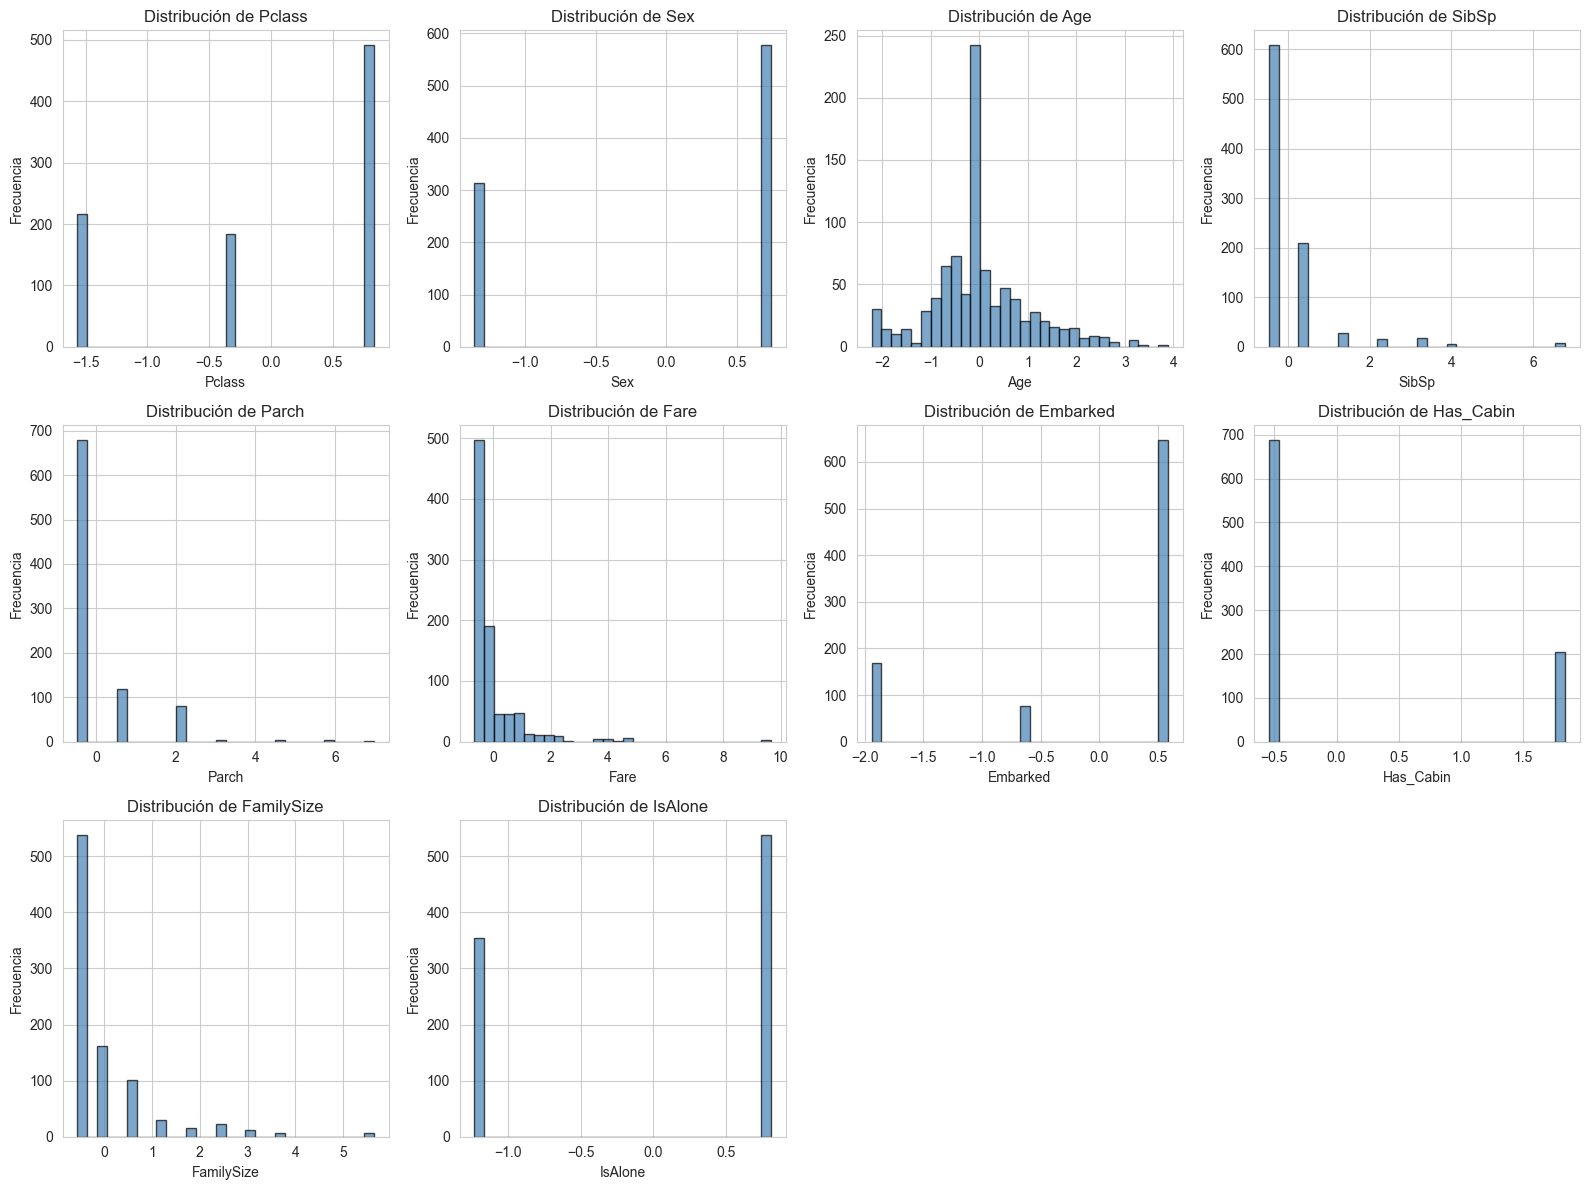

In [17]:
# ============================================
# 14. VISUALIZACIÓN DE DISTRIBUCIONES
# ============================================
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(X_train.columns):
    X_train[col].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar ejes vacíos
for j in range(len(X_train.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

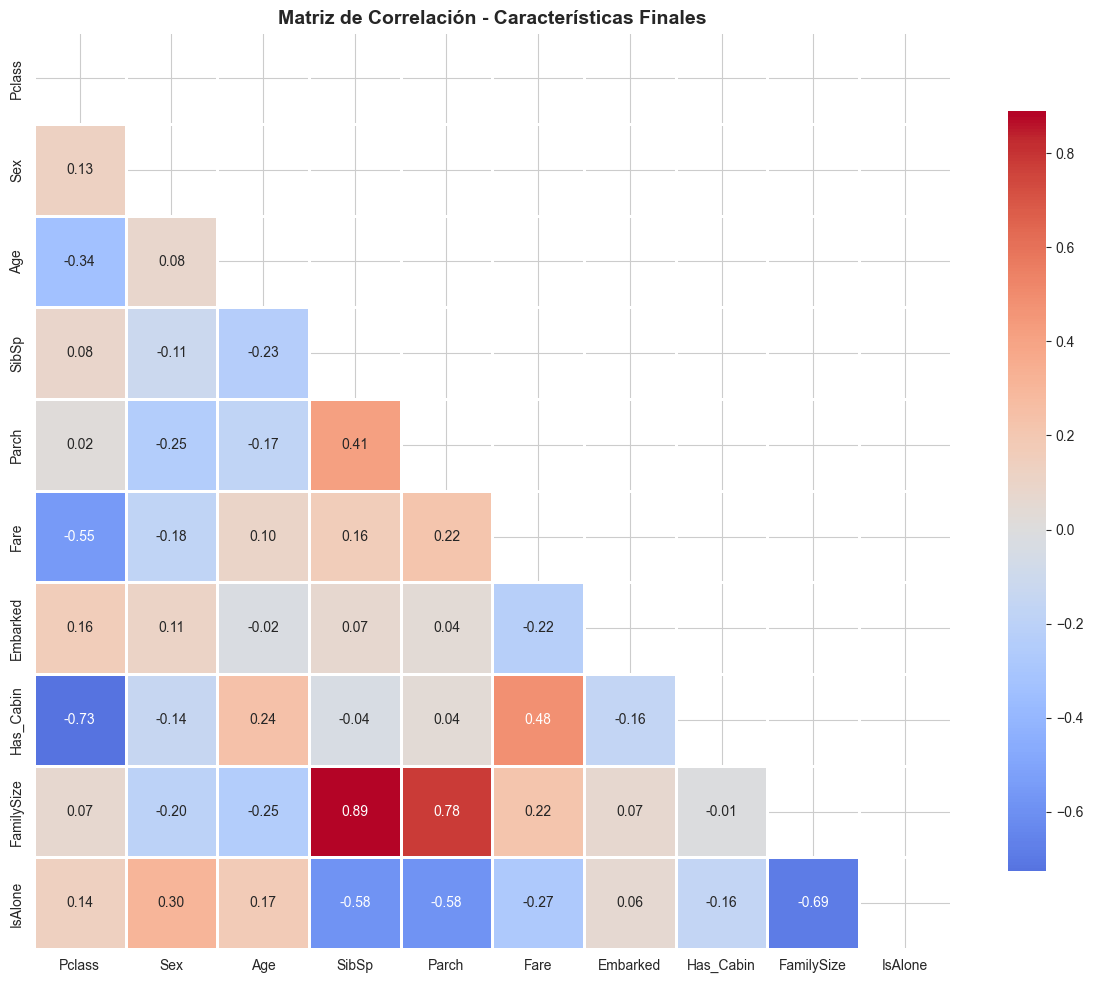

In [18]:
# ============================================
# 15. MATRIZ DE CORRELACIÓN
# ============================================
plt.figure(figsize=(12, 10))
corr = X_train.corr()

# Máscara para triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f',
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Características Finales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con Survived (si estuviera)
if 'Survived' in X_train.columns:
    print("\n Correlación con Survived:")
    corr_with_target = corr['Survived'].sort_values(ascending=False)
    print(corr_with_target)

 Entrenando Random Forest para ver importancia...

 Ranking de importancia:
Característica  Importancia
           Age     0.249753
          Fare     0.248890
           Sex     0.248001
        Pclass     0.071693
    FamilySize     0.044151
     Has_Cabin     0.039645
      Embarked     0.035373
         SibSp     0.026068
         Parch     0.023564
       IsAlone     0.012861


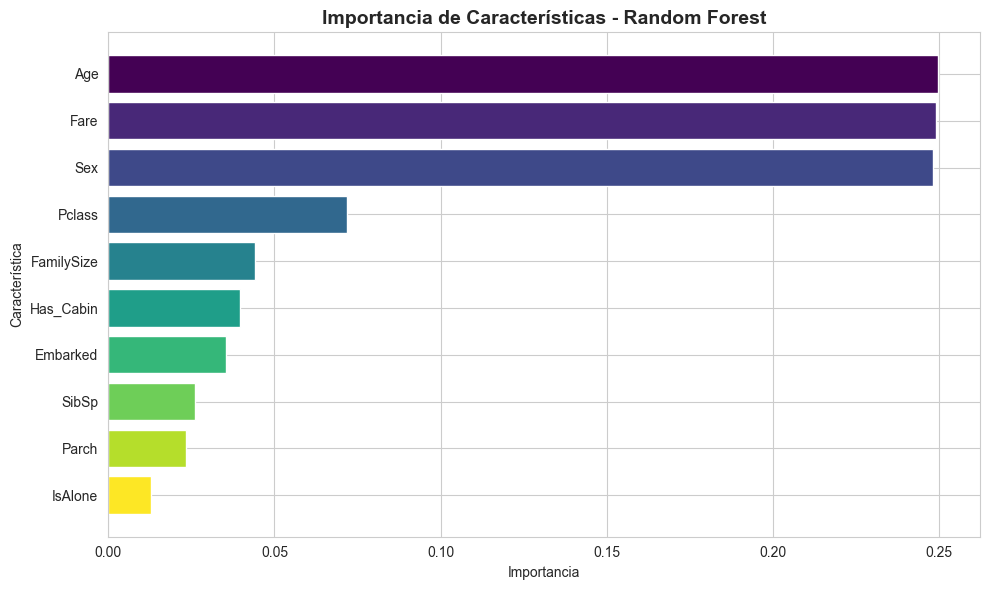


 Top 3 más importantes: Age, Fare, Sex


In [19]:
# ============================================
# 16. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================
from sklearn.ensemble import RandomForestClassifier

print(" Entrenando Random Forest para ver importancia...")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\n Ranking de importancia:")
print(importancias.to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(importancias)))
plt.barh(importancias['Característica'], importancias['Importancia'], color=colors)
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Top 3 más importantes: {', '.join(importancias['Característica'].head(3))}")

In [21]:
# ============================================
# 17. CONCLUSIONES FINALES
# ============================================
print("="*60)
print("📝 CONCLUSIONES DEL ANÁLISIS")
print("="*60)

print("""
✅ TRANSFORMACIONES REALIZADAS Y JUSTIFICACIÓN:

1. Age (imputación con mediana):
   - Motivo: 177 valores nulos (19.9%)
   - Justificación: La edad es clave para supervivencia (política niños primero)
   - Método: Mediana para evitar sesgo por outliers

2. Embarked (imputación con moda):
   - Motivo: Solo 2 valores nulos (0.2%)
   - Justificación: Puerto de embarque puede influir en acceso a botes
   - Método: Moda 'S' (Southampton) por ser el más común

3. Fare (solo para test):
   - Motivo: 1 valor nulo en test
   - Justificación: Necesario para predicción
   - Método: Mediana de Fare en train

4. Cabin → Has_Cabin (binaria):
   - Motivo: 687 valores nulos (77%)
   - Justificación: No se puede imputar, pero tener cabina es informativo
   - Método: Convertir a indicador binario (1 = tiene cabina)

5. FamilySize = SibSp + Parch + 1:
   - Motivo: Medir tamaño familiar
   - Justificación: Familias grandes podrían tener menor supervivencia
   - Evidencia: La tasa de supervivencia varía con el tamaño

6. IsAlone = (FamilySize == 1):
   - Motivo: Identificar pasajeros solos
   - Justificación: Comportamiento diferente en emergencias
   - Evidencia: Solos: {survival_alone[1]:.1%} vs Acompañados: {survival_alone[0]:.1%}

 CARACTERÍSTICAS FINALES ({len(X_train.columns)} variables):
{', '.join(X_train.columns)}

 CARACTERÍSTICAS MÁS IMPORTANTES:
{importancias.head(3).to_string(index=False)}

 Se justifican todas las transformaciones realizadas.
 No se requieren transformaciones adicionales.
""")

print("\n" + "="*60)
print(" ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*60)

📝 CONCLUSIONES DEL ANÁLISIS

✅ TRANSFORMACIONES REALIZADAS Y JUSTIFICACIÓN:

1. Age (imputación con mediana):
   - Motivo: 177 valores nulos (19.9%)
   - Justificación: La edad es clave para supervivencia (política niños primero)
   - Método: Mediana para evitar sesgo por outliers

2. Embarked (imputación con moda):
   - Motivo: Solo 2 valores nulos (0.2%)
   - Justificación: Puerto de embarque puede influir en acceso a botes
   - Método: Moda 'S' (Southampton) por ser el más común

3. Fare (solo para test):
   - Motivo: 1 valor nulo en test
   - Justificación: Necesario para predicción
   - Método: Mediana de Fare en train

4. Cabin → Has_Cabin (binaria):
   - Motivo: 687 valores nulos (77%)
   - Justificación: No se puede imputar, pero tener cabina es informativo
   - Método: Convertir a indicador binario (1 = tiene cabina)

5. FamilySize = SibSp + Parch + 1:
   - Motivo: Medir tamaño familiar
   - Justificación: Familias grandes podrían tener menor supervivencia
   - Evidencia: La t